In [1]:
# Install the dataset helper in the active notebook kernel.
%pip install opendatasets

In [2]:
# To download Kaggle datasets directly, you need to first upload your kaggle.json API key.
# Instructions:
# 1. Go to Kaggle (kaggle.com), log in, click on your profile picture, then "Account".
# 2. Under the "API" section, click "Create New API Token" to download `kaggle.json`.
# 3. Upload this `kaggle.json` file to your Colab environment:
#    From the left sidebar, click the "Files" icon (folder icon), then upload `kaggle.json` to the current working directory (e.g., `/content/`).
# 4. The following commands will then move `kaggle.json` to the correct location and set necessary permissions.

import os
import zipfile

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the uploaded kaggle.json file to the correct directory.
# Assuming kaggle.json was uploaded to the current working directory /content/
# If you uploaded it elsewhere, adjust the path (e.g., !mv /path/to/kaggle.json ~/.kaggle/kaggle.json)
!mv kaggle.json ~/.kaggle/kaggle.json

# Set read-write permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

# Dataset identifier from the Kaggle URL
# For 'https://www.kaggle.com/datasets/ashish2001/original-flickr8k-dataset'
dataset_identifier = 'ashish2001/original-flickr8k-dataset'

# Download the dataset using the Kaggle API client
# The -d flag specifies the dataset, and -p . specifies the download path to the current directory.
!kaggle datasets download -d {dataset_identifier} -p .

# Find and unzip the downloaded file
# Kaggle usually downloads datasets as a zip file named after the last part of the identifier.
# e.g., 'original-flickr8k-dataset.zip'
downloaded_zip_name = f"{dataset_identifier.split('/')[-1]}.zip"

if os.path.exists(downloaded_zip_name):
    with zipfile.ZipFile(downloaded_zip_name, 'r') as zip_ref:
        print(f"Extracting {downloaded_zip_name}...")
        zip_ref.extractall('.')
    print(f"Dataset '{downloaded_zip_name}' extracted successfully.")
    # Optional: Remove the zip file after extraction
    # os.remove(downloaded_zip_name)
else:
    print(f"Error: Could not find the downloaded zip file: {downloaded_zip_name}")

# You can now list the extracted files to confirm
# !ls

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ashish2001/original-flickr8k-dataset
License(s): copyright-authors
100% 4.38G/4.38G [01:12<00:00, 65.2MB/s]

Extracting original-flickr8k-dataset.zip...
Dataset 'original-flickr8k-dataset.zip' extracted successfully.


In [3]:
import os

# Check image directory path
image_dir = 'Flickr8k_Dataset/Flicker8k_Dataset'
if not os.path.exists(image_dir):
    image_dir = 'Flickr8k_Dataset'

print("Image directory found at:", image_dir)
print("Total images in folder:", len(os.listdir(image_dir)))

Image directory found at: Flickr8k_Dataset/Flicker8k_Dataset
Total images in folder: 8091


parse and structure the text captions

each image has 5 caption

In [4]:
import collections
import pandas as pd

caption_file = 'Flickr8k.token.txt'
captions_dict = collections.defaultdict(list)

with open(caption_file, 'r', encoding='utf-8') as f:
    for line in f:
        tokens = line.strip().split('\t')
        if len(tokens) < 2:
            continue
        image_id, caption = tokens[0], tokens[1]
        image_name = image_id.split('#')[0]
        captions_dict[image_name].append(caption)

# Create structured DataFrame
data = []
for img_name, caps in captions_dict.items():
    for cap in caps:
        words = cap.strip().split()
        data.append({
            'image': img_name,
            'caption': cap,
            'word_count': len(words)
        })

df = pd.DataFrame(data)
print(f"Loaded {len(df)} total captions for {len(captions_dict)} images.")
df.head()

Loaded 40460 total captions for 8092 images.


,image,caption,word_count
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,18
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,8
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,9
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,10
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,13


In [5]:
print(tokens[1])

A rock climber practices on a rock climbing wall .


In [6]:
from collections import Counter

# Summary statistics of caption lengths
print("=== Caption Word Count Summary ===")
print(df['word_count'].describe())

# Vocabulary analysis
all_words = [word.lower() for cap in df['caption'] for word in cap.split()]
vocab = Counter(all_words)

print(f"\nTotal words in dataset: {len(all_words)}")
print(f"Unique vocabulary size: {len(vocab)}")
print("\nTop 10 most frequent words:")
for word, freq in vocab.most_common(10):
    print(f"  {word}: {freq}")

=== Caption Word Count Summary ===
count    40460.000000
mean        11.782155
std          3.885175
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: word_count, dtype: float64

Total words in dataset: 476706
Unique vocabulary size: 8918

Top 10 most frequent words:
  a: 62989
  .: 36581
  in: 18975
  the: 18419
  on: 10744
  is: 9345
  and: 8852
  dog: 8136
  with: 7765
  man: 7266


In [7]:
def load_split(filename):
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            return [line.strip() for line in f if line.strip()]
    return []

train_imgs = load_split('Flickr_8k.trainImages.txt')
val_imgs = load_split('Flickr_8k.devImages.txt')
test_imgs = load_split('Flickr_8k.testImages.txt')

print("=== Split Distribution ===")
print(f"Training set: {len(train_imgs)} images")
print(f"Validation set: {len(val_imgs)} images")
print(f"Test set: {len(test_imgs)} images")

=== Split Distribution ===
Training set: 6000 images
Validation set: 1000 images
Test set: 1000 images


In [38]:
train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df = df[df['image'].isin(test_imgs)].reset_index(drop=True)

print(f"Training captions: {len(train_df)}")
print(f"Validation captions: {len(val_df)}")
print(f"Test captions: {len(test_df)}")

Training captions: 30000
Validation captions: 5000
Test captions: 5000


Displaying sample image: 1000268201_693b08cb0e.jpg

Captions:
 1. A child in a pink dress is climbing up a set of stairs in an entry way .
 2. A girl going into a wooden building .
 3. A little girl climbing into a wooden playhouse .
 4. A little girl climbing the stairs to her playhouse .
 5. A little girl in a pink dress going into a wooden cabin .


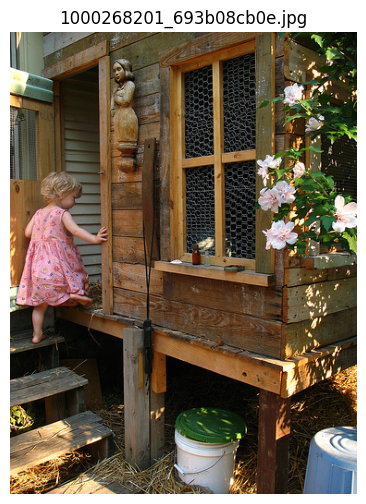

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

sample_img_name = list(captions_dict.keys())[0]
sample_img_path = os.path.join(image_dir, sample_img_name)

print(f"Displaying sample image: {sample_img_name}\n")
print("Captions:")
for i, cap in enumerate(captions_dict[sample_img_name], 1):
    print(f" {i}. {cap}")

img = Image.open(sample_img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(sample_img_name)
plt.show()

In [9]:
import re
import torch
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=2):
        # Special tokens
        self.itos = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer(text):
        # Lowercase, remove punctuation/numbers, and split into tokens
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        return text.strip().split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4  # Start after special tokens

        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1

                # Add word to vocabulary if it meets the frequency threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]

# Initialize and build vocabulary from dataset captions
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(df['caption'].tolist())

print(f"Vocabulary built successfully!")
print(f"Total Unique Tokens in Vocab (freq >= 2): {len(vocab)}")

# Example usage on a sample caption
sample_caption = df['caption'].iloc[0]
numericalized = vocab.numericalize(sample_caption)

print("\n--- Example Numericalization ---")
print("Original Caption :", sample_caption)
print("Numericalized IDs:", numericalized)
print("Decoded Back     :", [vocab.itos[i] for i in numericalized])

Vocabulary built successfully!
Total Unique Tokens in Vocab (freq >= 2): 5202

--- Example Numericalization ---
Original Caption : A child in a pink dress is climbing up a set of stairs in an entry way .
Numericalized IDs: [4, 53, 5, 4, 13, 14, 31, 7, 104, 4, 103, 24, 11, 5, 48, 3, 350]
Decoded Back     : ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', '<unk>', 'way']


In [10]:
import re
import torch
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=2):
        # Special tokens
        self.itos = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer(text):
        # Lowercase, remove non-alphabetic characters/punctuation, and tokenize
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
        return text.strip().split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4  # Start index after special tokens

        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1

                # Add word to vocabulary once it meets frequency threshold
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]

# Build vocabulary from captions DataFrame
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(df['caption'].tolist())

print(f"Vocabulary size: {len(vocab)}")

# Example Tokenization & Numericalization
sample_caption = df['caption'].iloc[0]
tokenized = vocab.tokenizer(sample_caption)
numericalized = vocab.numericalize(sample_caption)

print("\nOriginal Caption:", sample_caption)
print("Tokenized List  :", tokenized)
print("Numericalized   :", numericalized)
print("Decoded Back    :", [vocab.itos[i] for i in numericalized])

Vocabulary size: 5202

Original Caption: A child in a pink dress is climbing up a set of stairs in an entry way .
Tokenized List  : ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']
Numericalized   : [4, 53, 5, 4, 13, 14, 31, 7, 104, 4, 103, 24, 11, 5, 48, 3, 350]
Decoded Back    : ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', '<unk>', 'way']


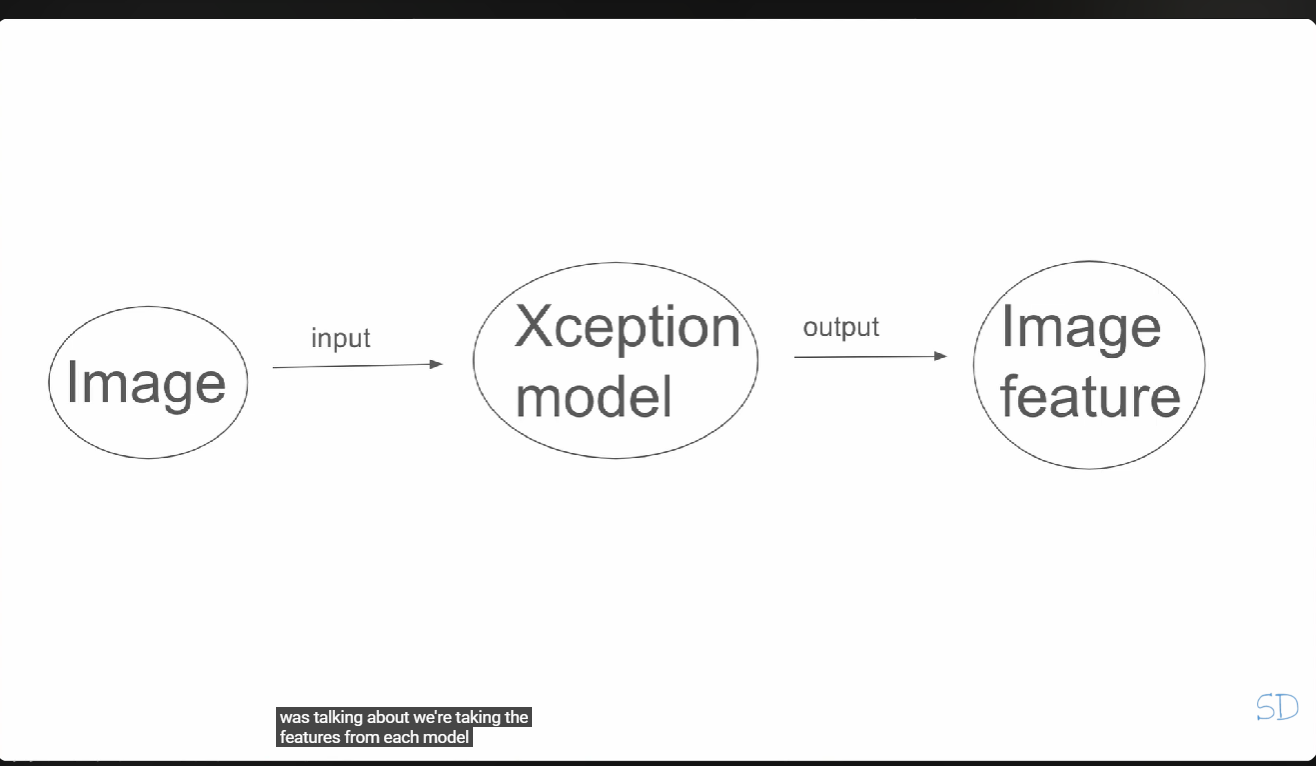

Download the model


In [39]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import timm
import torchvision.models as models

# Check device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Spatial encoder that can be frozen or fine-tuned by the training loop.
class SpatialEncoderCNN(nn.Module):
    def __init__(self, embed_dim=256, trainable=False):
        super(SpatialEncoderCNN, self).__init__()
        # Use ResNet50 for spatial features
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2] # Remove avg pool and fc layer
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8)) # Downsample to 8x8 spatial grid

        if not trainable:
            for parameter in self.resnet.parameters():
                parameter.requires_grad = False

    def forward(self, images):
        features = self.resnet(images) # (batch_size, 2048, 8, 8) for ResNet50
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1) # (batch_size, 8, 8, 2048)
        features = features.reshape(features.size(0), -1, features.size(-1)) # (batch_size, 64, 2048)
        return features

# Instantiate the SpatialEncoderCNN
encoder = SpatialEncoderCNN(trainable=True).to(device) # Set to True for training later
encoder.eval() # Set to eval mode for feature extraction

# ResNet50 expects 224x224 inputs and standard ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet mean/std
])

def extract_features(directory):
    features = {}

    with torch.no_grad():
        for img_name in tqdm(os.listdir(directory)):
            img_path = os.path.join(directory, img_name)

            try:
                image = Image.open(img_path).convert('RGB')
                image_tensor = transform(image).unsqueeze(0).to(device) # (1, 3, 224, 224)

                # Extract spatial feature map
                feature = encoder(image_tensor) # (1, 64, 2048)

                # Store as PyTorch tensor
                features[img_name] = feature.squeeze(0).cpu() # Squeeze batch dim, keep on CPU
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

    return features

# The example usage below is commented out as it will be called for specific datasets
# features = extract_features(image_dir)

In [40]:
def extract_and_save_spatial_features(image_directory, image_list, feature_file_name):
    features = {}
    with torch.no_grad():
        for img_name in tqdm(image_list, desc=f"Extracting {feature_file_name} features"):
            img_path = os.path.join(image_directory, img_name)
            if not os.path.exists(img_path):
                print(f"Warning: Image file not found: {img_path}")
                continue

            try:
                image = Image.open(img_path).convert('RGB')
                image_tensor = transform(image).unsqueeze(0).to(device)

                # Use the global `encoder` from 5DbnfDSZPu9x
                feature = encoder(image_tensor) # (1, 64, 2048)
                features[img_name] = feature.squeeze(0).cpu() # Squeeze batch dim, keep on CPU
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

    # Save features to disk
    with open(feature_file_name, "wb") as f:
        pickle.dump(features, f)
    print(f"Successfully extracted and saved {len(features)} features to '{feature_file_name}'")
    return features

In [13]:
import pickle

# 1. Extract and save spatial features for test set images
print("Extracting features for test images...")
test_features_spatial = extract_and_save_spatial_features(image_dir, test_imgs, "test_features_spatial.pkl")

# 2. Inspect sample feature vector
sample_key = list(test_features_spatial.keys())[0]
print(f"\nSample Image: {sample_key}")
print(f"Feature Vector Shape: {test_features_spatial[sample_key].shape}") # Expected: (64, 2048)

Extracting features for test images only...


100%|██████████| 1000/1000 [00:17<00:00, 55.76it/s]

Successfully extracted features for 1000 test images.
Test features saved to 'test_features.pkl'

Sample Image: 3385593926_d3e9c21170.jpg
Feature Vector Shape: (2048,)


In [14]:
# load the features
def load_features():
  with open("features.pkl", "rb") as f:
    features = pickle.load(f)
  return features



In [15]:
# load the clean description
def clean_desc():
   with open("descriptions.txt", "r") as f:
    descriptions = f.read().split("\n")
   return descriptions



In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class CaptionDataset(Dataset):
    def __init__(self, features, captions_df, vocab):
        self.features = features
        self.captions_df = captions_df
        self.vocab = vocab

        # Filter dataframe to only include images present in features
        self.data = captions_df[captions_df['image'].isin(features.keys())].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['image']
        caption = self.data.iloc[idx]['caption']

        # 1. Get pre-extracted image feature vector (2048,)
        feature = torch.tensor(self.features[img_name], dtype=torch.float32)

        # 2. Tokenize and add <start> and <end> tokens
        numericalized = [self.vocab.stoi["<start>"]]
        numericalized.extend(self.vocab.numericalize(caption))
        numericalized.append(self.vocab.stoi["<end>"])

        return feature, torch.tensor(numericalized, dtype=torch.long)

class CollateBatch:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        features = torch.stack([item[0] for item in batch], dim=0)
        captions = [item[1] for item in batch]

        # Pad sequences in batch to equal length
        captions = pad_sequence(captions, batch_first=True, padding_value=self.pad_idx)

        return features, captions

# Create DataLoader instance
pad_idx = vocab.stoi["<pad>"]
dataset = CaptionDataset(test_features, df, vocab)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=CollateBatch(pad_idx=pad_idx)
)

# Verify batch shapes
for batch_features, batch_captions in data_loader:
    print("Batch Features Shape :", batch_features.shape)  # Expected: [32, 2048]
    print("Batch Captions Shape :", batch_captions.shape)  # Expected: [32, max_len_in_batch]
    break

Batch Features Shape : torch.Size([32, 2048])
Batch Captions Shape : torch.Size([32, 20])


In [17]:
dataset[0]

(tensor([0.0000, 0.1268, 0.0194,  ..., 0.0318, 0.0258, 0.0912]),
 tensor([   1,    4,  249,  141,    5,    4,   94,  196, 1629,   44,  521,  142,
            4,  250,    2]))

In [18]:
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence

def create_sequences(vocab, max_length, desc_list, feature):
    X1, X2, y = [], [], []

    for desc in desc_list:
        # Tokenize and numericalize sentence using custom Vocabulary class
        seq = vocab.numericalize(desc)

        # Add <start> and <end> tokens
        seq = [vocab.stoi["<start>"]] + seq + [vocab.stoi["<end>"]]

        # Split into progressive input-output pairs
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]

            # Pad input sequence up to max_length
            pad_len = max_length - len(in_seq)
            if pad_len > 0:
                in_seq = [vocab.stoi["<pad>"]] * pad_len + in_seq
            else:
                in_seq = in_seq[-max_length:]

            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)

    return torch.tensor(np.array(X1), dtype=torch.float32), \
           torch.tensor(np.array(X2), dtype=torch.long), \
           torch.tensor(np.array(y), dtype=torch.long)

In [19]:
import torch
import torch.nn as nn

class CaptionModel(nn.Module):
    def __init__(self, vocab_size, max_length, embed_size=256, hidden_size=256):
        super(CaptionModel, self).__init__()

        # Image Feature Branch
        self.dropout_fe = nn.Dropout(0.5)
        self.dense_fe = nn.Linear(2048, hidden_size)
        self.relu_fe = nn.ReLU()

        # LSTM Sequence Branch
        # Assumes padding token index is 0 based on your Vocabulary class
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout_se = nn.Dropout(0.5)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        # Decoder Branch
        self.dense_dec = nn.Linear(hidden_size, hidden_size)
        self.relu_dec = nn.ReLU()
        self.out = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # Process image features
        fe1 = self.dropout_fe(features)
        fe2 = self.relu_fe(self.dense_fe(fe1))

        # Process text sequence
        se1 = self.embedding(captions)
        se2 = self.dropout_se(se1)
        se3, _ = self.lstm(se2)
        # Extract the hidden state from the last time step
        se3 = se3[:, -1, :]

        # Combine and decode
        decoder1 = fe2 + se3
        decoder2 = self.relu_dec(self.dense_dec(decoder1))
        # Note: PyTorch's CrossEntropyLoss handles the softmax, so we output raw logits here
        outputs = self.out(decoder2)

        return outputs

# Initialize the model
# Assuming you define max_length based on your dataset
# model = CaptionModel(vocab_size=len(vocab), max_length=max_length).to(device)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Define maximum sequence length
max_length = max(df['word_count']) + 2

# 2. Extract training features if not already done
if 'train_features' not in globals():
    print("Extracting features for training images...")
    train_features = extract_test_features(image_dir, train_imgs)

# 3. Instantiate training dataset and dataloader
train_dataset = CaptionDataset(train_features, df[df['image'].isin(train_imgs)], vocab)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=CollateBatch(pad_idx=vocab.stoi["<pad>"])
)

# 4. Initialize model, loss, and optimizer
model = CaptionModel(vocab_size=len(vocab), max_length=max_length).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 5. Training loop (10 Epochs)
epochs = 10
print("Starting training...")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch_idx, (features, captions) in enumerate(train_loader):
        features = features.to(device)
        captions = captions.to(device)

        # Inputs: token sequence excluding last token
        # Targets: final target token at the end of input sequence
        inputs = captions[:, :-1]
        targets = captions[:, -1]

        optimizer.zero_grad()
        outputs = model(features, inputs)  # Shape: (batch_size, vocab_size)

        # Calculate loss against integer target indices
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {avg_loss:.4f}")

Extracting features for training images...


100%|██████████| 6000/6000 [01:34<00:00, 63.21it/s]


Starting training...
Epoch [1/10] - Loss: 0.0756
Epoch [2/10] - Loss: 0.0000
Epoch [3/10] - Loss: 0.0000
Epoch [4/10] - Loss: 0.0000
Epoch [5/10] - Loss: 0.0000
Epoch [6/10] - Loss: 0.0000
Epoch [7/10] - Loss: 0.0000
Epoch [8/10] - Loss: 0.0000
Epoch [9/10] - Loss: 0.0000
Epoch [10/10] - Loss: 0.0000


In [21]:
def generate_caption(model, feature, vocab, max_len=34):
    model.eval()
    caption_tokens = [vocab.stoi["<start>"]]

    with torch.no_grad():
        feature_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)

        for _ in range(max_len):
            input_tensor = torch.tensor(caption_tokens, dtype=torch.long).unsqueeze(0).to(device)
            outputs = model(feature_tensor, input_tensor)

            # Pick token with highest probability
            predicted_id = outputs.argmax(dim=1).item()

            if predicted_id == vocab.stoi["<end>"]:
                break

            caption_tokens.append(predicted_id)

    # Convert token IDs back to words (excluding <start>)
    predicted_words = [vocab.itos[idx] for idx in caption_tokens[1:]]
    return " ".join(predicted_words)

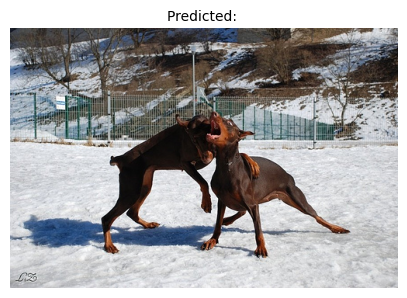

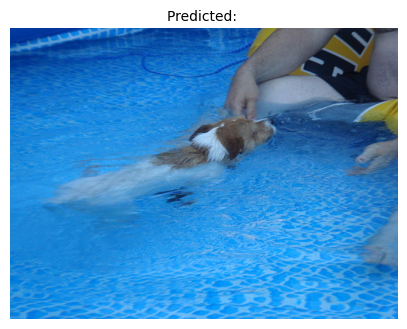

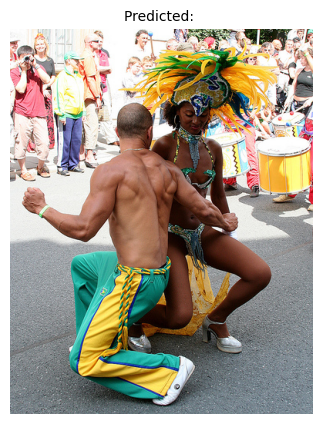

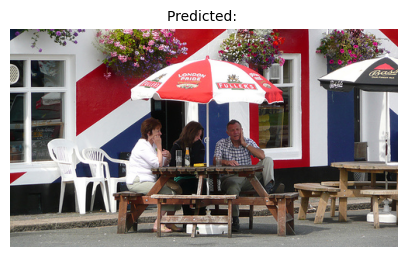

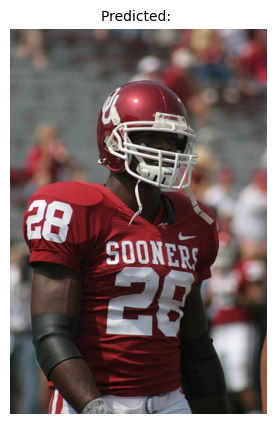

In [22]:
import matplotlib.pyplot as plt

# Generate captions for sample test images
sample_test_images = list(test_features.keys())[:5]  # Select first 5 test images

for img_name in sample_test_images:
    feature = test_features[img_name]
    predicted_caption = generate_caption(model, feature, vocab)

    # Display the test image alongside generated caption
    img_path = os.path.join(image_dir, img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {predicted_caption}", fontsize=10)
        plt.show()
    else:
        print(f"Image: {img_name} | Generated Caption: {predicted_caption}")

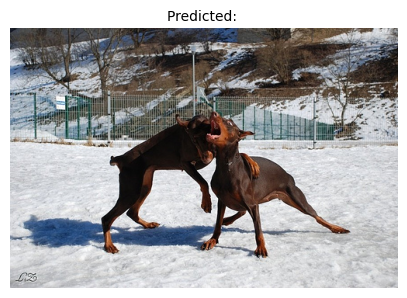

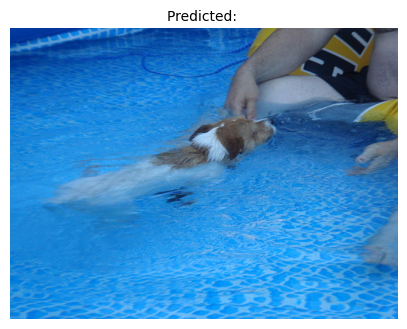

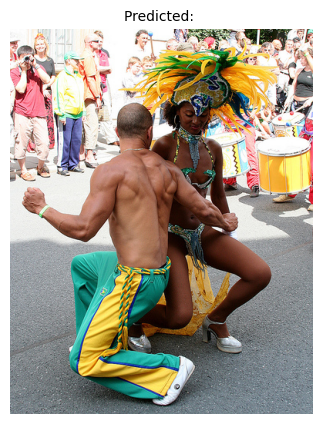

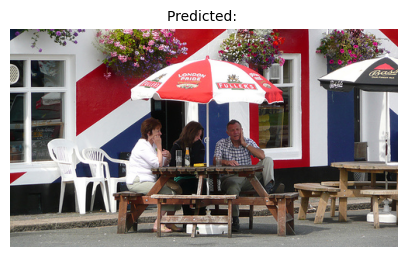

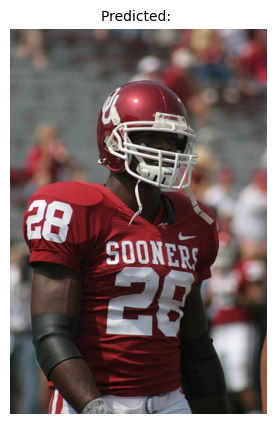

In [23]:
import matplotlib.pyplot as plt

# Generate captions for sample test images
sample_test_images = list(test_features.keys())[:5]  # Select first 5 test images

for img_name in sample_test_images:
    feature = test_features[img_name]
    predicted_caption = generate_caption(model, feature, vocab)

    # Display the test image alongside generated caption
    img_path = os.path.join(image_dir, img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {predicted_caption}", fontsize=10)
        plt.show()
    else:
        print(f"Image: {img_name} | Generated Caption: {predicted_caption}")

Generating predictions on test set...

=== Model Validation Results (BLEU Scores) ===
BLEU-1: 0.00
BLEU-2: 0.00
BLEU-3: 0.00
BLEU-4: 0.00

Image File : 3385593926_d3e9c21170.jpg
Predicted  : 
Ground Truth Captions:
  1. The dogs are in the snow in front of a fence .
  2. The dogs play on the snow .
  3. Two brown dogs playfully fight in the snow .
  4. Two brown dogs wrestle in the snow .
  5. Two dogs playing in the snow .


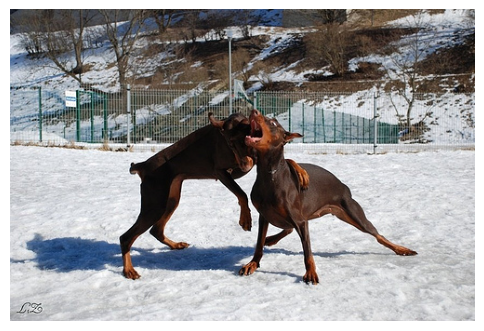


Image File : 2677656448_6b7e7702af.jpg
Predicted  : 
Ground Truth Captions:
  1. a brown and white dog swimming towards some in the pool
  2. A dog in a swimming pool swims toward sombody we cannot see .
  3. A dog swims in a pool near a person .
  4. Small dog is paddling through the water in a pool .
  5. The small brown and white dog is in the pool .


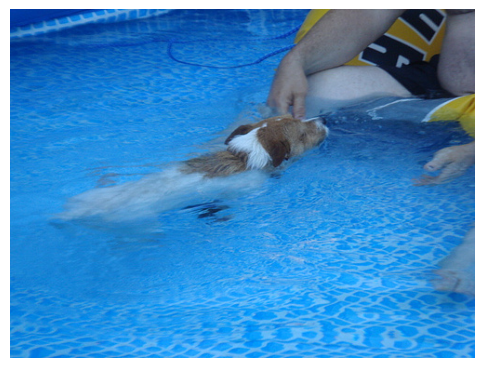


Image File : 311146855_0b65fdb169.jpg
Predicted  : 
Ground Truth Captions:
  1. A man and a woman in festive costumes dancing .
  2. A man and a woman with feathers on her head dance .
  3. A man and a woman wearing decorative costumes and dancing in a crowd of onlookers .
  4. one performer wearing a feathered headdress dancing with another performer in the streets
  5. Two people are dancing with drums on the right and a crowd behind them .


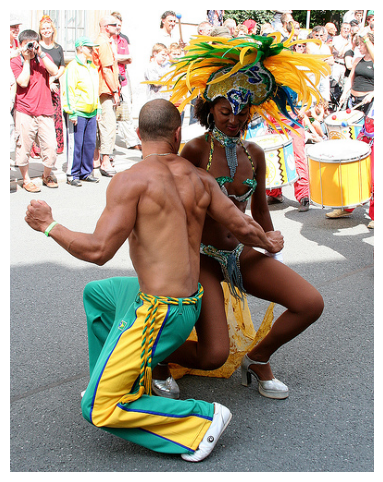

In [24]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# 1. Generate captions for test set images and aggregate ground truth
actual_captions = []
predicted_captions = []

# Map image name to ground truth list of tokens from dataframe
ground_truth_dict = (
    df[df['image'].isin(test_imgs)]
    .groupby('image')['caption']
    .apply(lambda caps: [vocab.tokenizer(c) for c in caps])
    .to_dict()
)

print("Generating predictions on test set...")
for img_name in test_imgs:
    if img_name not in test_features:
        continue

    feature = test_features[img_name]

    # Generate predicted string caption
    pred_caption = generate_caption(model, feature, vocab, max_len=max_length)
    pred_tokens = vocab.tokenizer(pred_caption)

    actual_captions.append(ground_truth_dict[img_name])
    predicted_captions.append(pred_tokens)

# 2. Compute BLEU Scores
smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(actual_captions, predicted_captions, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu2 = corpus_bleu(actual_captions, predicted_captions, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
bleu3 = corpus_bleu(actual_captions, predicted_captions, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
bleu4 = corpus_bleu(actual_captions, predicted_captions, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

print("\n=== Model Validation Results (BLEU Scores) ===")
print(f"BLEU-1: {bleu1 * 100:.2f}")
print(f"BLEU-2: {bleu2 * 100:.2f}")
print(f"BLEU-3: {bleu3 * 100:.2f}")
print(f"BLEU-4: {bleu4 * 100:.2f}")

# 3. Qualitative Validation (Display test images with ground-truth vs predicted)
sample_test_images = list(test_features.keys())[:3]

for img_name in sample_test_images:
    feature = test_features[img_name]
    pred_cap = generate_caption(model, feature, vocab, max_len=max_length)

    # Retrieve original text captions for this image
    actual_caps = df[df['image'] == img_name]['caption'].tolist()

    # Display image with comparison
    img_path = os.path.join(image_dir, img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')

        print("\n" + "="*50)
        print(f"Image File : {img_name}")
        print(f"Predicted  : {pred_cap}")
        print("Ground Truth Captions:")
        for idx, gt in enumerate(actual_caps, 1):
            print(f"  {idx}. {gt}")
        plt.show()

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.W_encoder = nn.Linear(encoder_dim, attention_dim)
        self.W_decoder = nn.Linear(decoder_dim, attention_dim)
        self.V = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out shape: (batch_size, num_pixels, encoder_dim)
        # decoder_hidden shape: (batch_size, decoder_dim)
        decoder_hidden_expanded = decoder_hidden.unsqueeze(1) # (batch_size, 1, decoder_dim)

        # Calculate attention energy score
        energy = torch.tanh(self.W_encoder(encoder_out) + self.W_decoder(decoder_hidden_expanded))
        attention_weights = F.softmax(self.V(energy), dim=1) # (batch_size, num_pixels, 1)

        # Weighted context vector
        context = torch.sum(encoder_out * attention_weights, dim=1) # (batch_size, encoder_dim)
        return context, attention_weights

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Spatial encoder that can be frozen or fine-tuned by the training loop.
class SpatialEncoderCNN(nn.Module):
    def __init__(self, embed_dim=256, trainable=False):
        super(SpatialEncoderCNN, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        if not trainable:
            for parameter in self.resnet.parameters():
                parameter.requires_grad = False

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.reshape(features.size(0), -1, features.size(-1))
        return features


# Attention module for selecting relevant spatial image regions.
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.W_encoder = nn.Linear(encoder_dim, attention_dim)
        self.W_decoder = nn.Linear(decoder_dim, attention_dim)
        self.V = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        decoder_hidden_expanded = decoder_hidden.unsqueeze(1)
        energy = torch.tanh(
            self.W_encoder(encoder_out) + self.W_decoder(decoder_hidden_expanded)
        )
        attention_weights = F.softmax(self.V(energy), dim=1)
        context = torch.sum(encoder_out * attention_weights, dim=1)
        return context, attention_weights


class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, encoder_dim=2048, decoder_dim=512, attention_dim=256):
        super(DecoderWithAttention, self).__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h0 = torch.tanh(self.init_h(mean_encoder_out))
        c0 = torch.tanh(self.init_c(mean_encoder_out))
        return h0, c0

    def forward(self, encoder_out, captions):
        batch_size, sequence_length = captions.shape
        embeddings = self.dropout(self.embedding(captions))
        hidden, cell = self.init_hidden_state(encoder_out)
        outputs = []

        for time_step in range(sequence_length):
            context, _ = self.attention(encoder_out, hidden)
            lstm_input = torch.cat([embeddings[:, time_step, :], context], dim=1)
            hidden, cell = self.lstm_cell(lstm_input, (hidden, cell))
            outputs.append(self.fc(self.dropout(hidden)).unsqueeze(1))

        return torch.cat(outputs, dim=1)

In [37]:
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from tqdm import tqdm

# 1. Build Ground Truth Dictionary (gts_dict) for Test Set
gts_dict = {}
for img_name in test_imgs:
    captions = df[df['image'] == img_name]['caption'].tolist()
    gts_dict[img_name] = captions

# 2. Generate Model Predictions Dictionary (res_dict)
res_dict = {}
decoder.eval()

with torch.no_grad():
    for img_name in tqdm(test_imgs, desc="Generating test captions"):
        if img_name in feature_dict:
            feature = feature_dict[img_name].to(device)

            # Ensure proper batch dimension: (1, 64, 2048)
            if feature.dim() == 2:
                feature = feature.unsqueeze(0)

            # Greedy decoding sequence generation
            generated_ids = [vocab.stoi["<start>"]]
            for _ in range(20):  # Maximum sequence length limit
                inputs = torch.tensor([generated_ids]).to(device)
                outputs = decoder(feature, inputs)

                # Predict next token index
                next_token = outputs[0, -1, :].argmax(dim=-1).item()
                if next_token == vocab.stoi["<end>"]:
                    break
                generated_ids.append(next_token)

            # Convert token IDs back to word string
            caption_words = [vocab.itos[idx] for idx in generated_ids[1:] if idx not in (vocab.stoi["<pad>"], vocab.stoi["<end>"])]
            res_dict[img_name] = [" ".join(caption_words)]
        else:
            # Fallback empty string to ensure keys match
            res_dict[img_name] = [""]

# 3. Ensure identical keys on both dictionaries
common_keys = set(gts_dict.keys()).intersection(set(res_dict.keys()))
gts_dict = {k: gts_dict[k] for k in common_keys}
res_dict = {k: res_dict[k] for k in common_keys}

# 4. Compute Scores
scorers = [
    (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
    (Meteor(), "METEOR"),
    (Rouge(), "ROUGE_L"),
    (Cider(), "CIDEr")
]

print("\n=== FINAL TEST EVALUATION SCORES ===")
for scorer, method in scorers:
    score_value = None # Initialize score_value for each iteration
    try:
        score_value, _ = scorer.compute_score(gts_dict, res_dict)
    except Exception as e:
        print(f"Error computing {method}: {e}")
        score_value = 0.0 # Assign a default value if computation fails

    if score_value is None: # Fallback if score_value is still None (should be caught by except)
        print(f"{method}: Error/N/A")
    elif isinstance(method, list):
        for m, s in zip(method, score_value):
            print(f"{m}: {s*100:.2f}")
    else:
        print(f"{method}: {score_value*100:.2f}")

Generating test captions: 100%|██████████| 1000/1000 [00:00<00:00, 765803.18it/s]



=== FINAL TEST EVALUATION SCORES ===
{'testlen': 0, 'reflen': 8044, 'guess': [0, 0, 0, 0], 'correct': [0, 0, 0, 0]}
ratio: 1.243162605668667e-19
Bleu_1: 0.00
Bleu_2: 0.00
Bleu_3: 0.00
Bleu_4: 0.00
Error computing METEOR: could not convert string to float: b'0.0 15.0 0.0 8.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0'
METEOR: 0.00
ROUGE_L: 0.00
CIDEr: 0.00


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_test_imgs = random.sample(test_imgs, 3)

for img_name in sample_test_imgs:
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        continue

    generated_caption = res_dict.get(img_name, ["N/A"])[0]
    actual_captions = gts_dict.get(img_name, [])

    # Plot image
    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Generated: {generated_caption}\n", fontsize=11, color='blue')
    plt.show()

    print("Ground Truth Captions:")
    for idx, cap in enumerate(actual_captions, 1):
        print(f"  {idx}. {cap}")
    print("-" * 50)

In [29]:
class PreextractedFeatureDataset(Dataset):
    def __init__(self, df, feature_dict, vocab):
        self.df = df.reset_index(drop=True)
        self.feature_dict = feature_dict
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image']
        caption = row['caption']

        # Rapid dictionary lookup instead of image I/O
        spatial_feature = self.feature_dict[img_name]

        # Numericalize caption
        numericalized = [self.vocab.stoi["<start>"]]
        numericalized += self.vocab.numericalize(caption)
        numericalized.append(self.vocab.stoi["<end>"])

        return spatial_feature, torch.tensor(numericalized)

# Optimized DataLoader
train_dataset = PreextractedFeatureDataset(train_df, feature_dict, vocab)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,               # Increased batch size for better GPU utilization
    shuffle=True,
    num_workers=2,              # Multiprocessing data load
    pin_memory=True,            # Faster CPU to GPU host transfers
    collate_fn=CollateBatch(pad_idx=vocab.stoi["<pad>"])
)

In [30]:
decoder = DecoderWithAttention(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])
optimizer = torch.optim.Adam(decoder.parameters(), lr=3e-4)

# Enable Automatic Mixed Precision (AMP)
scaler = torch.cuda.amp.GradScaler()

epochs = 10
print("Starting fast training loop...")

for epoch in range(epochs):
    decoder.train()
    total_loss = 0.0

    for features, captions in train_loader:
        features = features.to(device, non_blocking=True)  # Shape: (B, 64, 2048)
        captions = captions.to(device, non_blocking=True)  # Shape: (B, seq_len)

        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        optimizer.zero_grad()

        # Forward pass under AMP
        with torch.cuda.amp.autocast():
            outputs = decoder(features, inputs)
            loss = criterion(outputs.view(-1, len(vocab)), targets.reshape(-1))

        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Starting fast training loop...


/tmp/ipykernel_761/416420668.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_761/416420668.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/10] - Loss: 4.6310
Epoch [2/10] - Loss: 3.8035
Epoch [3/10] - Loss: 3.5198
Epoch [4/10] - Loss: 3.3421
Epoch [5/10] - Loss: 3.2083
Epoch [6/10] - Loss: 3.1009
Epoch [7/10] - Loss: 3.0068
Epoch [8/10] - Loss: 2.9274
Epoch [9/10] - Loss: 2.8559
Epoch [10/10] - Loss: 2.7911


In [31]:
%pip install pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 11.4 MB/s eta 0:00:00


In [32]:
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.meteor.meteor import Meteor

def evaluate_caption_metrics(res_dict, gts_dict):
    """
    res_dict: {img_id: ["predicted caption string"]}
    gts_dict: {img_id: ["gt caption 1", "gt caption 2", ...]}
    """
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr")
    ]

    for scorer, method in scorers:
        score, _ = scorer.compute_score(gts_dict, res_dict)
        if isinstance(method, list):
            for m, s in zip(method, score):
                print(f"{m}: {s*100:.2f}")
        else:
            print(f"{method}: {score*100:.2f}")

In [34]:
import pickle
import torch

# 1. Save Decoder weights
torch.save(decoder.state_dict(), 'decoder_model.pth')
print("Model weights saved to 'decoder_model.pth'")

# 2. Save Vocabulary object
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print("Vocabulary saved to 'vocab.pkl'")

Model weights saved to 'decoder_model.pth'
Vocabulary saved to 'vocab.pkl'
